# V18: Hierarchical System & Visual Quality Comparison

Notebook ini adalah versi ekspansi dari V18 yang menyertakan analisis kualitas sinyal melalui perbandingan Confusion Matrix antara model Standar, V17, dan V18 Hierarchical.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from hmmlearn import hmm
from sklearn.metrics import confusion_matrix, precision_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Environment Ready")

✅ Environment Ready


## 1. Data Loading & Global HMM (Layer 1)

In [2]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_index_ret = returns.mean(axis=1)

market_log_ret = np.log1p(market_index_ret).replace([np.inf, -np.inf], np.nan).dropna()
X_global = market_log_ret.values.reshape(-1, 1)

global_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
global_hmm.fit(X_global)

bull_global = np.argmax([global_hmm.means_[i][0] for i in range(2)])
global_regime = pd.Series(global_hmm.predict(X_global) == bull_global, index=market_log_ret.index).astype(int)

print(f"🌍 Global HMM Ready. Bullish State: {bull_global}")

🌍 Global HMM Ready. Bullish State: 0


## 2. Local HMMs & Feature Engineering

In [3]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

cryptos = data.columns.tolist()
local_hmm_map = {}
all_features = []
all_targets = []
test_data_map = {}

for symbol in cryptos:
    asset_price = data[symbol]
    asset_ret = asset_price.pct_change().dropna()
    
    # Layer 2: Local HMM
    asset_log_ret = np.log1p(asset_ret).replace([np.inf, -np.inf], np.nan).dropna()
    X_local = asset_log_ret.values.reshape(-1, 1)
    local_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, random_state=42)
    local_hmm.fit(X_local)
    local_hmm_map[symbol] = local_hmm
    
    # Layer 3: XGBoost Features
    df_feat = pd.DataFrame(index=asset_price.index)
    df_feat['Vol_20'] = asset_ret.rolling(20).std()
    df_feat['Mom_20'] = asset_ret.rolling(20).mean()
    df_feat['RSI_14'] = calculate_rsi(asset_ret, 14)
    df_feat['Ret_Lag1'] = asset_ret.shift(1)
    target = (asset_ret.rolling(5).mean().shift(-5) > 0).astype(int)
    combined = df_feat.join(target.rename('Target')).dropna()
    
    train = combined[combined.index.year <= 2024]
    test = combined[combined.index.year == 2025]
    
    all_features.append(train.drop('Target', axis=1))
    all_targets.append(train['Target'])
    test_data_map[symbol] = test

X_train_stacked = pd.concat(all_features)
y_train_stacked = pd.concat(all_targets)
print(f"✅ Training Data Ready: {len(X_train_stacked)} samples")

Model is not converging.  Current: 2299.356006604264 is not greater than 2299.356201638781. Delta is -0.00019503451676428085
Model is not converging.  Current: 844.3231316026418 is not greater than 844.3257388010204. Delta is -0.0026071983786550845
Model is not converging.  Current: 3387.8931471676633 is not greater than 3387.9455183468604. Delta is -0.0523711791970527


✅ Training Data Ready: 14891 samples


## 3. Train Universal XGBoost

In [4]:
universal_xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
universal_xgb.fit(X_train_stacked, y_train_stacked)
print("🚀 Universal XGBoost trained.")

🚀 Universal XGBoost trained.


## 4. Visual Quality Comparison (Confusion Matrix)

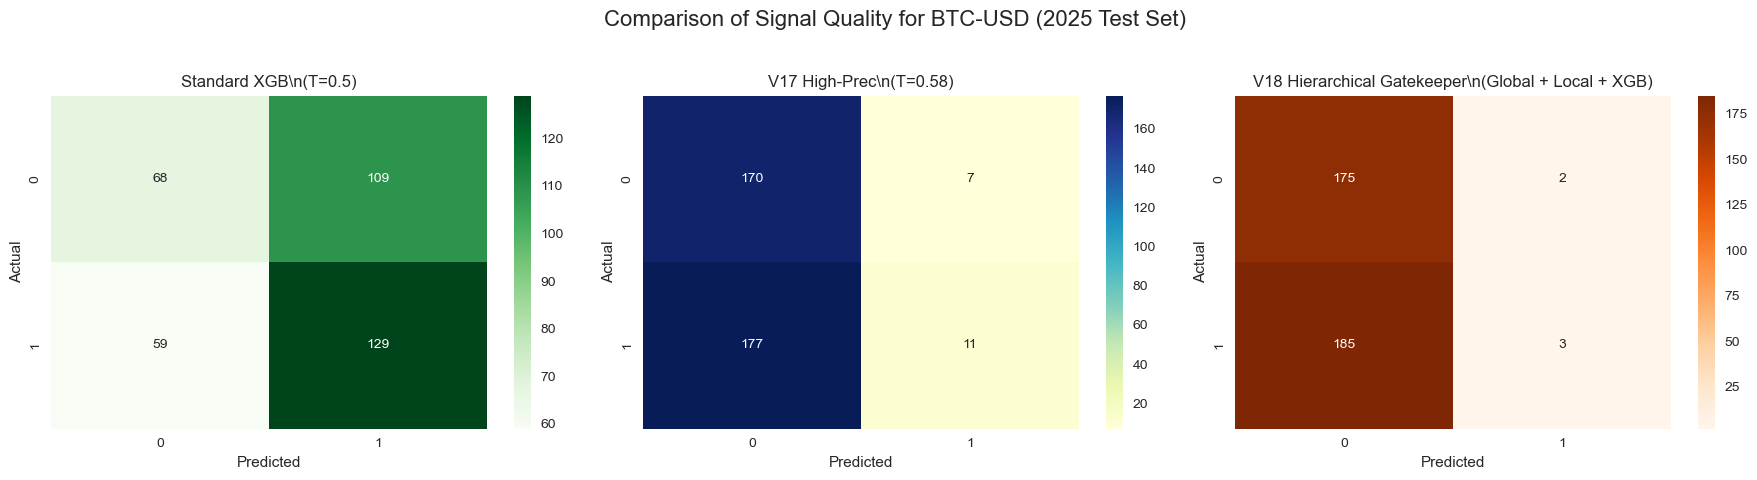

In [5]:
threshold = 0.58
symbol_to_plot = 'BTC-USD'

if symbol_to_plot in test_data_map:
    test_df = test_data_map[symbol_to_plot]
    X_test_plot = test_df.drop('Target', axis=1)
    y_test_plot = test_df['Target']

    # 1. Global Filter (Layer 1)
    asset_global_regime_plot = global_regime.reindex(X_test_plot.index, method='ffill').fillna(0).values
    
    # 2. Local Filter (Layer 2)
    asset_ret_test_plot = data[symbol_to_plot].pct_change().reindex(X_test_plot.index)
    X_local_test_plot = np.log1p(asset_ret_test_plot.fillna(0)).replace([np.inf, -np.inf], 0).values.reshape(-1, 1)
    local_model_plot = local_hmm_map[symbol_to_plot]
    bull_local_plot = np.argmax([local_model_plot.means_[i][0] for i in range(2)])
    asset_local_regime_plot = (local_model_plot.predict(X_local_test_plot) == bull_local_plot).astype(int)

    # 3. XGBoost Probabilities (Layer 3)
    probs_plot = universal_xgb.predict_proba(X_test_plot)[:, 1]

    # Generate Predictions for different levels
    preds_std = (probs_plot >= 0.5).astype(int)
    preds_v17 = (probs_plot >= threshold).astype(int)
    preds_v18 = (asset_global_regime_plot == 1) & (asset_local_regime_plot == 1) & (probs_plot >= threshold)
    preds_v18 = preds_v18.astype(int)

    # Visualizing
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.heatmap(confusion_matrix(y_test_plot, preds_std), annot=True, fmt='d', cmap='Greens', ax=ax[0])
    ax[0].set_title(f"Standard XGB\\n(T=0.5)")
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Actual")

    sns.heatmap(confusion_matrix(y_test_plot, preds_v17), annot=True, fmt='d', cmap='YlGnBu', ax=ax[1])
    ax[1].set_title(f"V17 High-Prec\\n(T={threshold})")
    ax[1].set_xlabel("Predicted")
    ax[1].set_ylabel("Actual")

    sns.heatmap(confusion_matrix(y_test_plot, preds_v18), annot=True, fmt='d', cmap='Oranges', ax=ax[2])
    ax[2].set_title(f"V18 Hierarchical Gatekeeper\\n(Global + Local + XGB)")
    ax[2].set_xlabel("Predicted")
    ax[2].set_ylabel("Actual")

    plt.suptitle(f"Comparison of Signal Quality for {symbol_to_plot} (2025 Test Set)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print(f"Data for {symbol_to_plot} not found in test set.")